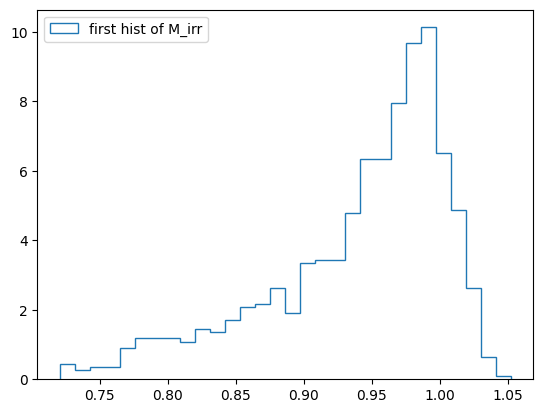

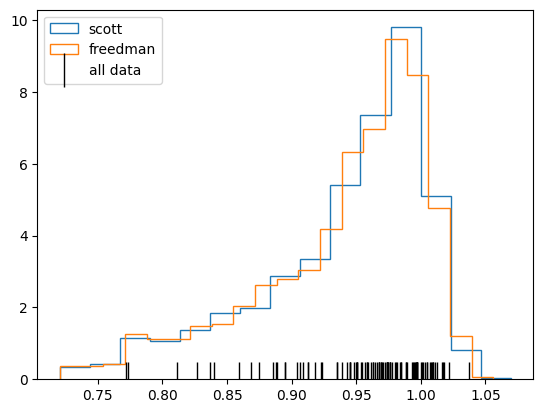

In [285]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
import sklearn 
from random import sample
from sklearn.neighbors import KernelDensity
import scipy
import scipy.integrate as integrate
import astropy.visualization.hist


sigma=0.02
mu=1

chi=np.random.uniform(0,1,1000)
M=np.random.normal(mu,sigma,1000)

def f(X): 
    return np.sqrt((1+np.sqrt(1-X**2))/2)

M_irr=M*f(chi)
plt.hist(M_irr,30, histtype='step', density=True, label='first hist of M_irr')
plt.legend()
plt.show()

# rules of thumb of the bin's number
astropy.visualization.hist(M_irr, bins="scott", histtype="step",density=True, label='scott')
astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True, label='freedman')
plt.plot(M_irr[:100], 0*M_irr[:100], '|', color='k', markersize=25, label="all data");
plt.legend()
plt.show()

  

### Same number of objects in each bin.

11 35


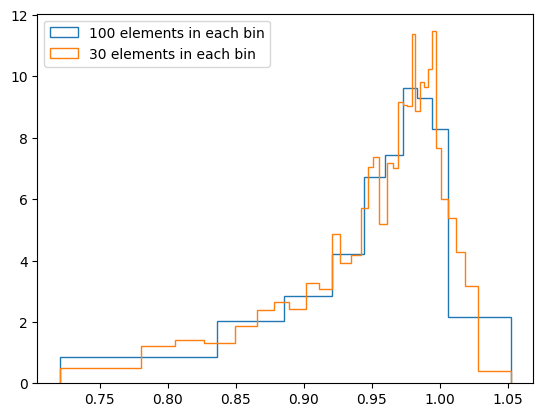

In [ ]:
#selection of one element over 100 or 30 
#with append np.max bins array covers the entire interval 
bins100 = np.append(np.sort(M_irr)[::100], np.max(M_irr))   #100 in each bin 
bins30 = np.append(np.sort(M_irr)[::30], np.max(M_irr))     #30 elements in each bin
print(len(bins100),len(bins30))  

# passing a vector to bins= we give the bins edges 
plt.hist(M_irr, bins=bins100, density=True, histtype="step", label='100 elements in each bin') 
plt.hist(M_irr, bins=bins30, density=True, histtype="step", label='30 elements in each bin') #so bins ae smaller 
plt.legend()
plt.show()

Using KDE

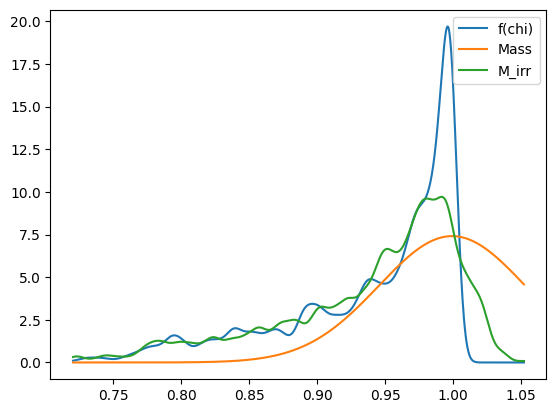

In [286]:
xgrid = np.linspace(M_irr.min(),M_irr.max(),1000) #x of KDE 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):

    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFmir = kde_sklearn(M_irr,bandwidth=0.005,kernel="gaussian") 
PDFGauss = kde_sklearn(M,bandwidth=0.05,kernel="gaussian") 
PDFfchi = kde_sklearn(f(chi),bandwidth=0.005,kernel="gaussian")  
plt.plot(xgrid,PDFfchi, label='f(chi)')
plt.plot(xgrid,PDFGauss, label='Mass') 
plt.plot(xgrid,PDFmir, label='M_irr')
plt.legend(loc='best')
plt.show()


### Plotting the PDF of f(chi)

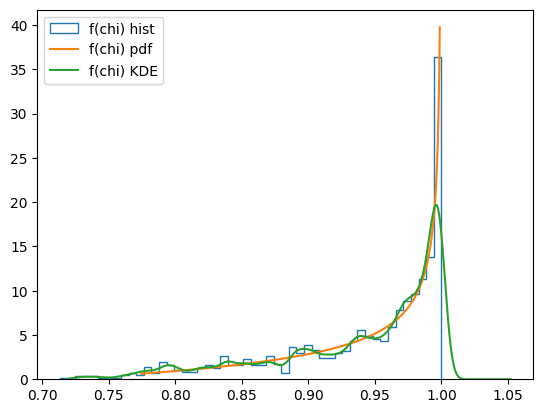

In [287]:
def f_pdfs(f):                               #pdf of chi 
    return 2*(2*f**2-1)/np.sqrt(1-f**2)

minf=np.min(f(chi))
maxf=np.max(f(chi)) #è positiva da 0.7 in poi

xgrid2 = np.linspace(0.1,0.98,1000) #possibile codominio  da 0 ad 1 

#L'ISTOGRAMMA DI f(CHI) TORNA
plt.hist(f(chi),bins=50, histtype='step', density=True, label='f(chi) hist') 

#amche con f(chi) ordinato ok, ma bisogna togliere gli estremi fastidiosi 

plt.plot(f(xgrid2),f_pdfs(f(xgrid2)), label='f(chi) pdf')
plt.plot(xgrid,PDFfchi, label='f(chi) KDE')
plt.legend(loc='upper left')
plt.show()

nor=integrate.quad(f_pdfs,minf,maxf) #nel codominio di f f_pdf è normalizzata



### Plotting the PDF of M_irr

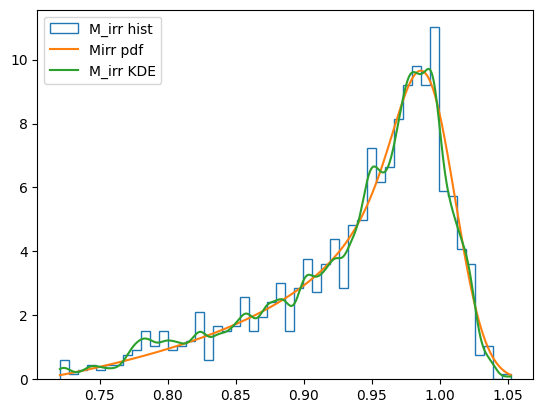

In [288]:
def to_int(f,Mirr):                                                   #integrate in f and Mirr is a parameter   
    return np.exp(-(Mirr/f-mu)**2/(2*sigma**2))*f_pdfs(f)/2/f

def Mirr_pdf(Mirr):                                                                      
    integral=integrate.quad(to_int,0.71,1,args=(Mirr,)) 
    return integral[0]*np.sqrt(2/np.pi)/sigma                         #only the result of integral and not the error 

Mirrmin=np.min(M_irr)
Mirrmax=np.max(M_irr) 

xgrid3 = np.linspace(Mirrmin,Mirrmax,1000)    
s = [Mirr_pdf(Mirr) for Mirr in xgrid3]                             #because integrate.quad accept only scalar

plt.hist(M_irr,bins=50, histtype='step', density=True, label='M_irr hist')
plt.plot(xgrid3,s, label='Mirr pdf')
plt.plot(xgrid,PDFmir, label='M_irr KDE')

plt.legend(loc='upper left')
plt.show() 


### Ks Comparison ###

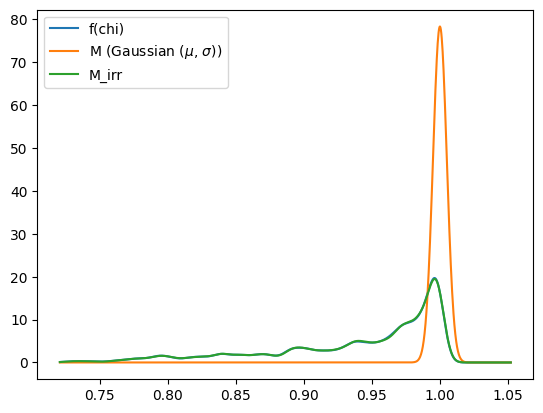

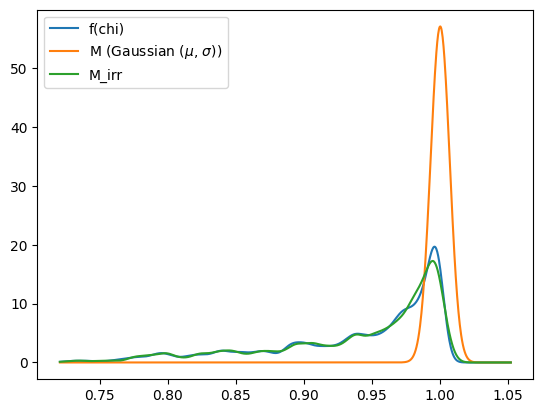

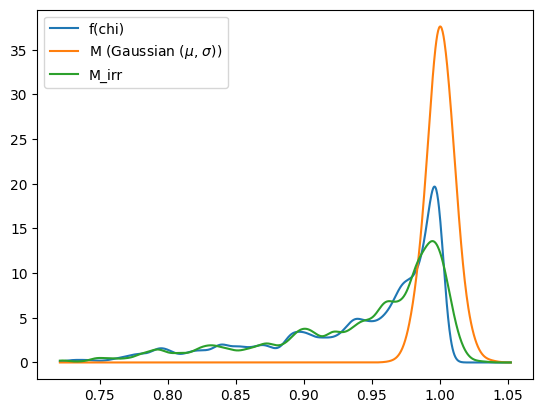

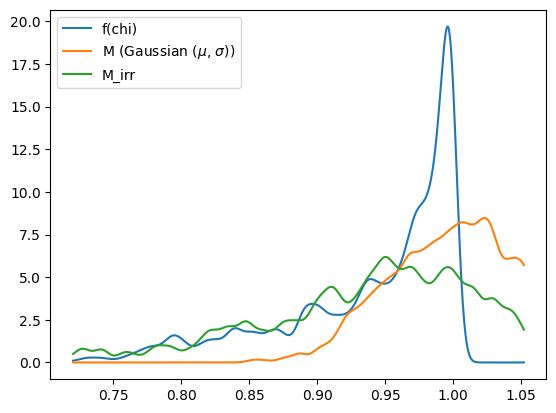

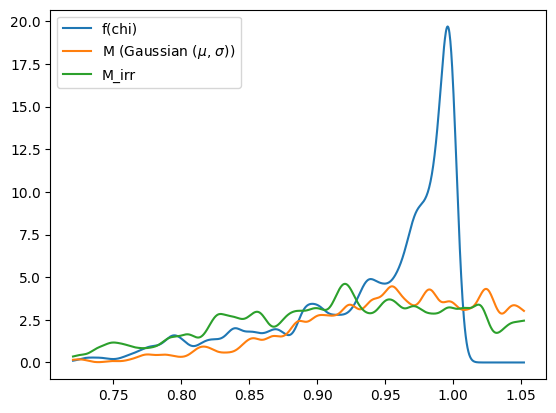

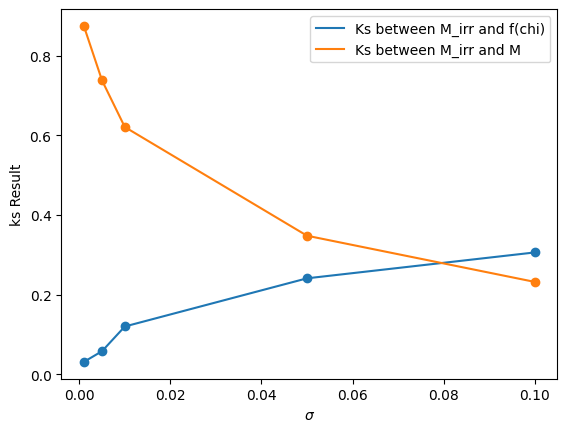

In [289]:
ks1=[]
ks2=[]

sigmas=[0.001,0.005,0.01,0.05,0.1]
for i in sigmas:
    Mk=np.random.normal(mu,i,1000)
    Mk_irr=Mk*f(chi)

    PDFChi = kde_sklearn(f(chi),bandwidth=0.005,kernel="gaussian") #plot always same f(chi)
    PDFMass = kde_sklearn(Mk,bandwidth=0.005,kernel="gaussian")  
    PDFMirr = kde_sklearn(Mk_irr,bandwidth=0.005,kernel="gaussian")  

    plt.plot(xgrid,PDFChi, label="f(chi)")
    plt.plot(xgrid,PDFMass, label=r"M (Gaussian ($\mu$, $\sigma$))")
    plt.plot(xgrid,PDFMirr, label="M_irr")
    
    plt.legend()
    plt.show()

    ks1.append(scipy.stats.ks_2samp(Mk_irr,f(chi)).statistic)
    ks2.append(scipy.stats.ks_2samp(Mk_irr,Mk).statistic)

plt.scatter(sigmas,ks1)
plt.plot(sigmas,ks1, label="Ks between M_irr and f(chi)")
plt.scatter(sigmas,ks2)
plt.plot(sigmas,ks2, label="Ks between M_irr and M")
plt.legend()
plt.xlabel(r"$\sigma$")
plt.ylabel("ks Result")
plt.show()
